# Бенчмарк: латентность и пропускная способность

Живое воспроизведение таблицы из README и [docs §5.4](../docs/05-eksperimenty-i-rezultaty.md): латентность от числа MC-проходов $M$ для трёх длин. Протокол: 5 прогревочных + 20 замеров, bf16-автокаст, B=1.

In [1]:
# Подъём до корня репозитория (тетрадь открывается в notebooks/)
import os
while not os.path.exists("inference.py") and os.getcwd() != os.path.dirname(os.getcwd()):
    os.chdir("..")
assert os.path.exists("inference.py"), "Откройте тетрадь внутри репозитория BbValidator"
print("Корень репозитория:", os.getcwd())

Корень репозитория: /home/pc/PycharmProjects/BbValidator


In [2]:
%matplotlib inline
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from inference import _autocast_ctx, build_model, center_coords, parse_pdb_to_backbone
from model.heads_loss import predict_with_uncertainty

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
model = build_model("checkpoints/best_model.pth", device)

/home/pc/PycharmProjects/BbValidator/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Устройство: cuda
Загрузка весов из checkpoints/best_model.pth...


In [3]:
SAMPLES = ["data/3MYC.pdb", "data/2RJW.pdb", "data/my_protein_2.pdb"]
MC_RUNS = [4, 8, 16, 32]
WARMUP, ITERATIONS = 5, 20

tensors = {}
for path in SAMPLES:
    coords_np = center_coords(parse_pdb_to_backbone(path))
    coords = torch.from_numpy(coords_np).unsqueeze(0).to(device)
    mask = torch.ones((1, coords.shape[1]), dtype=torch.bool, device=device)
    tensors[path] = (coords, mask)
    print(f"{path}: L = {coords.shape[1]}")

data/3MYC.pdb: L = 64


data/2RJW.pdb: L = 134
data/my_protein_2.pdb: L = 242


In [4]:
def latency_ms(coords, mask, mc_runs):
    """Протокол benchmark.py: 5 прогревочных + N замеров, cuda-синхронизация."""
    for _ in range(WARMUP):
        with _autocast_ctx(device):
            _ = predict_with_uncertainty(model, coords, mask, mc_runs=mc_runs)
    if device.type == "cuda":
        torch.cuda.synchronize()
    times = []
    for _ in range(ITERATIONS):
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        with _autocast_ctx(device):
            _ = predict_with_uncertainty(model, coords, mask, mc_runs=mc_runs)
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000)
    return times

rows = []
for path, (coords, mask) in tensors.items():
    L = coords.shape[1]
    for m in MC_RUNS:
        t = latency_ms(coords, mask, m)
        avg, p90 = float(np.mean(t)), float(np.percentile(t, 90))
        rows.append({"L": L, "M": m, "latency_ms": avg, "p90_ms": p90,
                     "цепей/с": 1000.0 / avg})
        print(f"L={L} M={m:>2}: {avg:6.1f} мс  ({1000.0 / avg:.0f} цепей/с)")

df = pd.DataFrame(rows)

L=64 M= 4:    9.8 мс  (102 цепей/с)


L=64 M= 8:   17.0 мс  (59 цепей/с)


L=64 M=16:   31.8 мс  (31 цепей/с)


L=64 M=32:   60.2 мс  (17 цепей/с)


L=134 M= 4:    9.8 мс  (102 цепей/с)


...

L=134 M=32:   62.7 мс  (16 цепей/с)


L=242 M= 4:   10.0 мс  (100 цепей/с)


L=242 M= 8:   17.7 мс  (56 цепей/с)


L=242 M=16:   33.0 мс  (30 цепей/с)


L=242 M=32:   63.7 мс  (16 цепей/с)


In [5]:
df.pivot(index="L", columns="M", values="latency_ms").round(1)

M,4,8,16,32
L,,,,
64,9.8,17.0,31.8,60.2
134,9.8,17.3,36.2,62.7
242,10.0,17.7,33.0,63.7


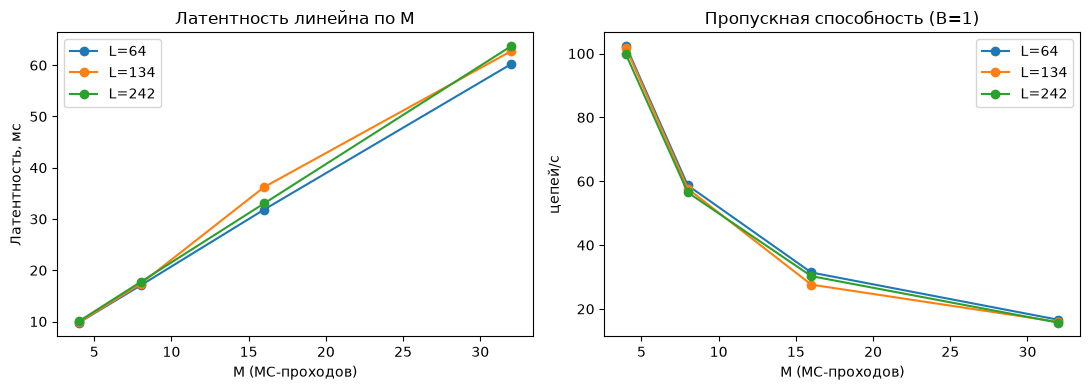

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for L, d in df.groupby("L"):
    axes[0].plot(d["M"], d["latency_ms"], marker="o", label=f"L={L}")
    axes[1].plot(d["M"], d["цепей/с"], marker="o", label=f"L={L}")
axes[0].set_xlabel("M (MC-проходов)")
axes[0].set_ylabel("Латентность, мс")
axes[0].set_title("Латентность линейна по M")
axes[0].legend()
axes[1].set_xlabel("M (MC-проходов)")
axes[1].set_ylabel("цепей/с")
axes[1].set_title("Пропускная способность (B=1)")
axes[1].legend()
plt.tight_layout()
plt.show()

Стоимость складывается из одноразового фронтенда (~2 мс) и $M$ проходов энкодера (~1.9 мс/проход), поэтому латентность линейна по $M$ и слабо зависит от длины в диапазоне 64–242 остатка. Полная таблица из 50 замеров — в README (раздел про бенчмарк).